In [96]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import math
import pickle
import networkx as nx
import random 
import EoN
import pandas as pd

# Haselmere Town
Simulating an hypothetical epidemic in Haselmere town of England, UK to illustrate the application of Susceptible-Infected-Recovered (SIR) model. 

In [ ]:
# Load and preprocess the data
## file with user interactions and distances
df1 = pd.read_csv("Kissler_DataS1.csv",header=None)
df1.columns = ["time_idx", "user_1","user_2","distance"]

## file with time index and corresponding timestamps
df2 = pd.read_csv("Kissler_DataS2.csv",header=None)
df2.columns = ["time_idx","time_BST"]

## Merge the two dataframes on the time index
df = pd.merge(df1, df2, on="time_idx")

## Convert time_BST to datetime and extract month, day, and hour
df['time_BST'] = pd.to_datetime(df['time_BST'])
df['month'] = df['time_BST'].dt.month
df['day'] = df['time_BST'].dt.day
df['hour'] = df['time_BST'].dt.hour

## Filter for close contacts (distance <= 5 meters)
df_close_contact_during_daytime = df[(df['distance']<=5)]
df_hourly_contacts = df_close_contact_during_daytime.groupby(['hour','user_1','user_2']).time_idx.count().reset_index().rename(columns={'time_idx':'contact_count'})

## Create a contact network graph from the hourly contacts dataframe
G = nx.from_pandas_edgelist(df_hourly_contacts, 'user_1', 'user_2')


Text(0.5, 1.0, 'Contact network at 8am')

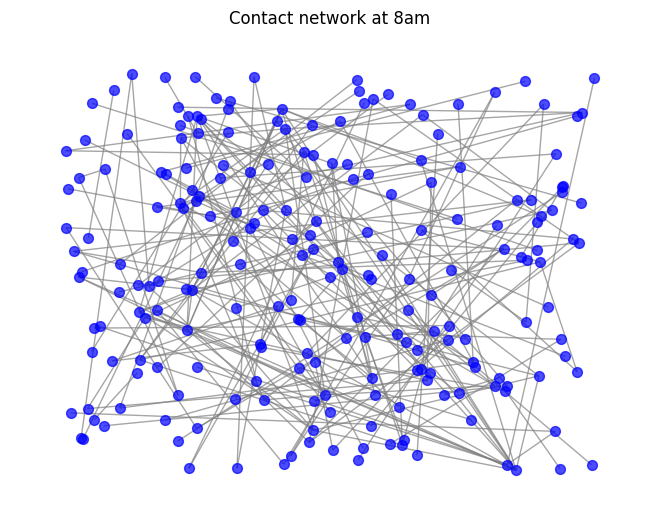

In [ ]:
## Visualize the contact network at a specific hour (e.g., 8am)
G_1 = nx.from_pandas_edgelist(df_hourly_contacts[df_hourly_contacts.hour==8], 'user_1', 'user_2')
nx.draw(G_1, with_labels=False, node_size=50, node_color='blue', edge_color='gray', alpha=0.7, pos=nx.random_layout(G))
plt.title("Contact network at 8am")

In [163]:


# Total population
N = len(G.nodes)

# Initial conditions
I0 = 1
R0 = 0
S0 = N - I0 - R0

# Parameters
beta = 0.13   # infection rate
gamma = 1/72  # recovery rate

# Time grid (hours)
t = np.arange(0, 100,1)

## Model 1: SIR at population level

In [257]:
# Initial state vector
y0 = [S0, I0, R0]

In [258]:


# SIR model equations
def sir_model(y, t, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]


# Solve ODE
solution = odeint(sir_model, y0, t, args=(beta, gamma))
S, I, R = solution.T

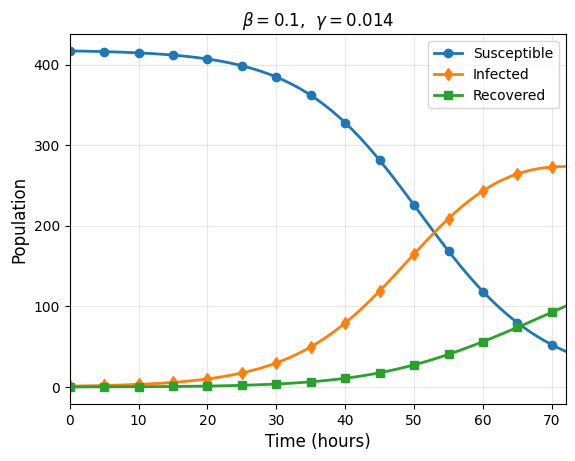

In [259]:


# Plot
plt.plot(t, S, label='Susceptible', linewidth=2, marker='o',markevery=5)
plt.plot(t, I, label='Infected', linewidth=2,marker='d',markevery=5)
plt.plot(t, R, label='Recovered', linewidth=2, marker='s',markevery=5)

plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Population', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.title(f'$\\beta={np.round(beta,1)}$,  $\\gamma={np.round(gamma,3)}$', fontsize=12)
plt.xlim(0,72)
plt.show()

## Model 2: SIR at individual level with static graph

In [168]:
results = []
for i in range(100):
    infected_nodes = random.sample(list(G.nodes), I0)  # Randomly select initial infected nodes

    # Run the SIR simulation using the Gillespie algorithm
    sim = EoN.Gillespie_SIR(G=G, tau=beta, gamma=gamma, initial_infecteds=infected_nodes,
                            return_full_data=True, tmax=100)
    t_ = sim.t()
    S = sim.S()
    I = sim.I()
    R = sim.R()
    results.append([t_, S, I, R])

In [252]:
cnt = 75
S_array = np.array([0]*cnt)
I_array = np.array([0]*cnt)
R_array = np.array([0]*cnt)
for sub_ls in results:
    t_, S, I, R = sub_ls
    t_df = pd.DataFrame(t_,columns=['time_OG'])
    t_df['time_1'] = np.round(t_,0)
    t_df['rank'] = t_df.groupby('time_1').cumcount() + 1
    req_time_idx = list(t_df.groupby('time_1')['rank'].idxmax())

    if len(req_time_idx) >=cnt:
        S_req = S[req_time_idx[:cnt]]
        I_req = I[req_time_idx[:cnt]]
        R_req = R[req_time_idx[:cnt]]
        S_array = np.vstack([S_array, S_req])
        I_array = np.vstack([I_array, I_req])
        R_array = np.vstack([R_array, R_req])

        
plot_time = t_[req_time_idx[:cnt]]

In [253]:
S_avg = np.mean(S_array, axis=0)
I_avg = np.mean(I_array, axis=0)
R_avg = np.mean(R_array, axis=0)

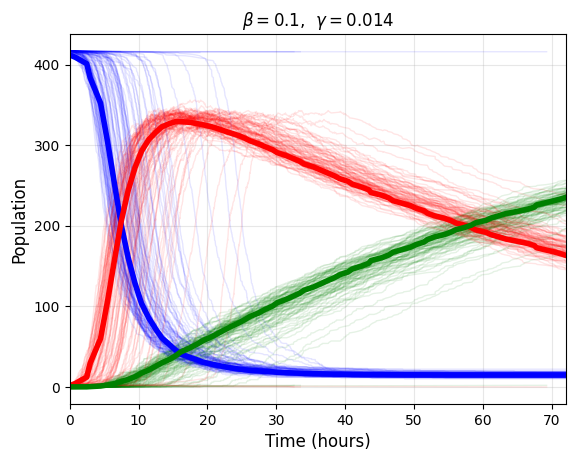

In [255]:
for sub_ls in results:
    t_, S, I, R = sub_ls
    plt.plot(t_, S, label='Susceptible', linewidth=1, color='blue',alpha=0.1)
    plt.plot(t_, I, label='Infected', linewidth=1,color='red',alpha=0.1)
    plt.plot(t_, R, label='Recovered', linewidth=1,color='green',alpha=0.1)
    
plt.plot(plot_time, S_avg, label='Average Susceptible', linewidth=4, color='blue')
plt.plot(plot_time, I_avg, label='Average Infected', linewidth=4,color='red')
plt.plot(plot_time, R_avg, label='Average Recovered',  linewidth=4,color='green')

plt.grid(alpha=0.3)
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Population', fontsize=12)
plt.xlim(0,72)
plt.title(f'$\\beta={np.round(beta,1)}$,  $\\gamma={np.round(gamma,3)}$', fontsize=12)
plt.show()

# Dengue Model


In [ ]:
S_H0, I_H0, R_H0, S_M0, I_M0 = 999, 1, 0, 5000, 0
beta_H = 0.2
gamma_H = 1/180
d_H = 0.001
beta_M = 0.1
d_M = 0.01
N_H = 1000
b_M = 50
b_H = 5

t = np.arange(0, 50, 1)



# Initial state vector
y0 = [S_H0, I_H0, R_H0, S_M0, I_M0]



In [ ]:
def sir_human_mosquito_model(y, t, beta_H, gamma_H, d_H, beta_M, d_M, N_H, b_M,b_H):
    # y = np.maximum(y, 0)
    S_H, I_H, R_H, S_M, I_M  = y
    dS_Hdt = b_H-beta_H * S_H * I_M / N_H - d_H * S_H
    dI_Hdt = beta_H * S_H * I_M / N_H  - gamma_H * I_H - d_H * I_H
    dR_Hdt = gamma_H * I_H - d_H * R_H

    dS_Mdt = b_M-beta_M * S_M * I_H / N_H - d_M * S_M
    dI_Mdt = beta_M * S_M * I_H / N_H - d_M * I_M
    
    return [dS_Hdt, dI_Hdt, dR_Hdt, dS_Mdt, dI_Mdt]
solution = odeint(sir_human_mosquito_model, y0, t, args=(beta_H, gamma_H, d_H, beta_M, d_M, N_H,b_M,b_H))
S_H, I_H, R_H, S_M, I_M = solution.T

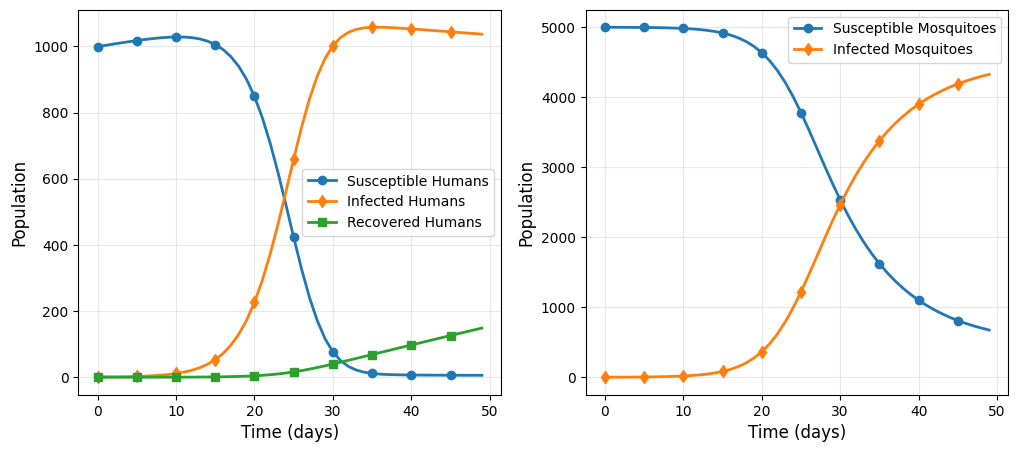

In [149]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(t, S_H, label='Susceptible Humans', linewidth=2, marker='o',markevery=5)
plt.plot(t, I_H, label='Infected Humans', linewidth=2,marker='d',markevery=5)
plt.plot(t, R_H, label='Recovered Humans', linewidth=2, marker='s',markevery=5)
plt.xlabel('Time (days)', fontsize=12)
plt.ylabel('Population', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t, S_M, label='Susceptible Mosquitoes', linewidth=2, marker='o',markevery=5)
plt.plot(t, I_M, label='Infected Mosquitoes', linewidth=2, marker='d',markevery=5)     
plt.xlabel('Time (days)', fontsize=12)
plt.ylabel('Population', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()